In [2]:
from resources.cut_off_black_segments import cut_off_black_segments
import nibabel as nib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
LABELS_PATH = NIFTI_DIR / "train_labels_JNDlMjr.csv"
FILE_NAME = "08liuqdn.nii.gz"
FILE_PATH = NIFTI_DIR / FILE_NAME

labels = pd.read_csv(LABELS_PATH)
files = sorted(NIFTI_DIR.glob("*.nii.gz"))

In [13]:
original_img = nib.load(FILE_PATH)
original = original_img.get_fdata(dtype=np.float32)

cropped, _ = cut_off_black_segments(
    path=FILE_PATH,
    threshold=0,
    margin=1,
)


1/10: 01nouhtc.nii.gz


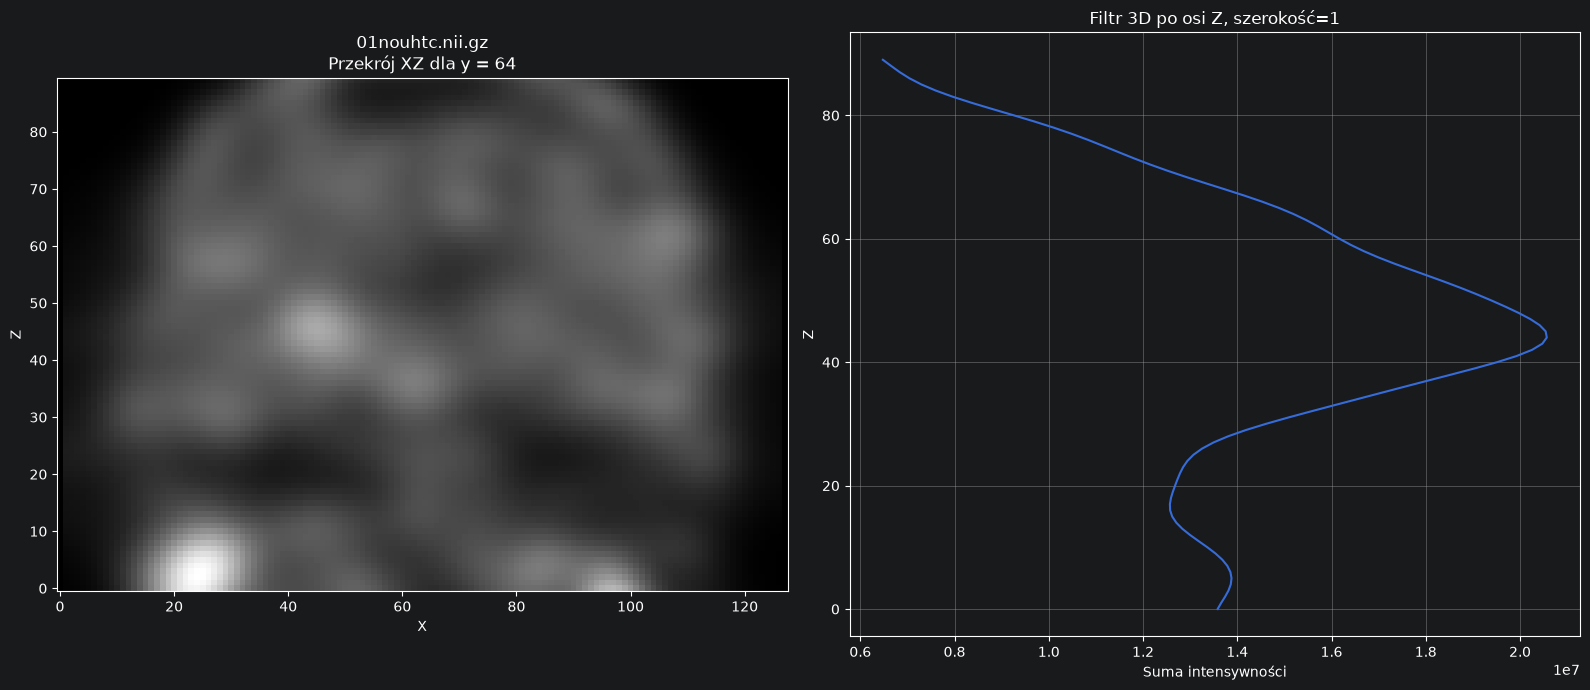


2/10: 0224wk0y.nii.gz


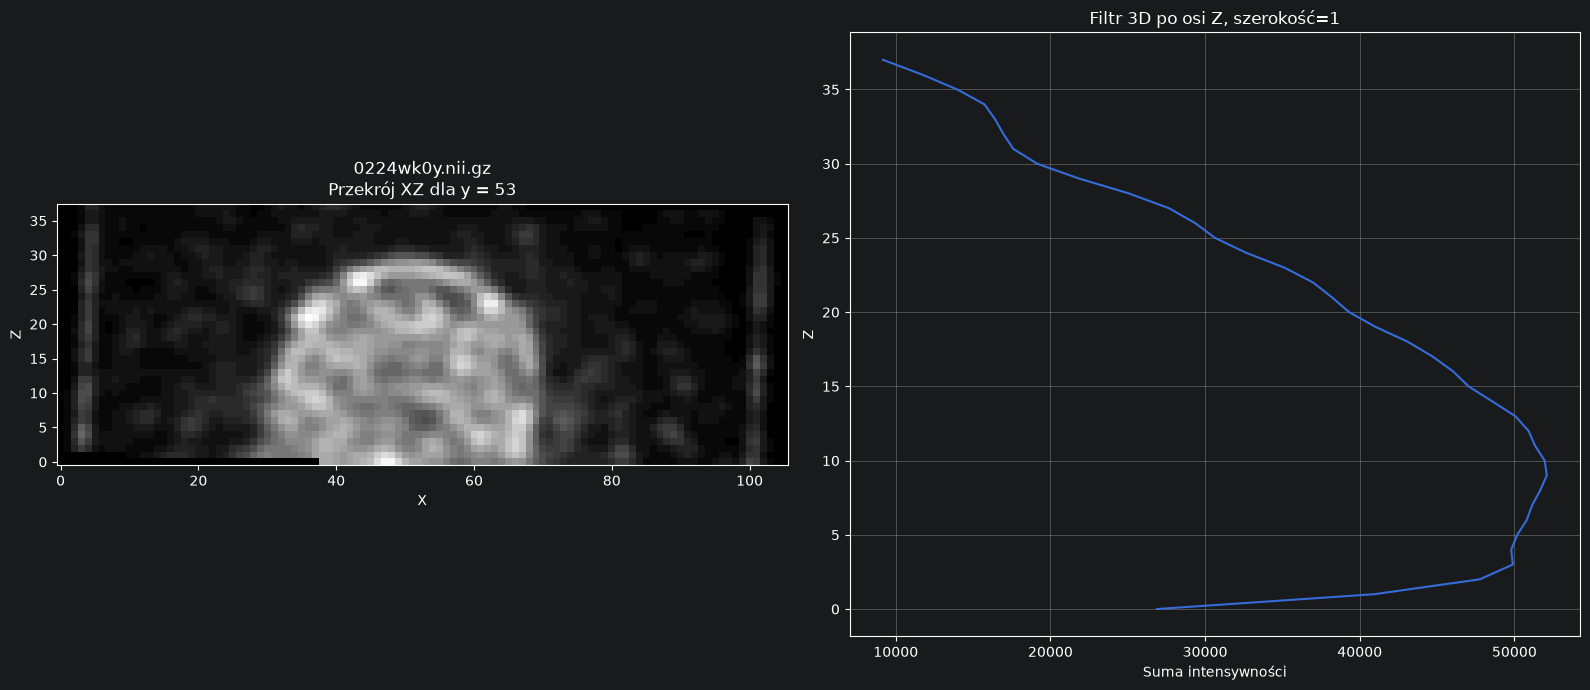


3/10: 049enulq.nii.gz


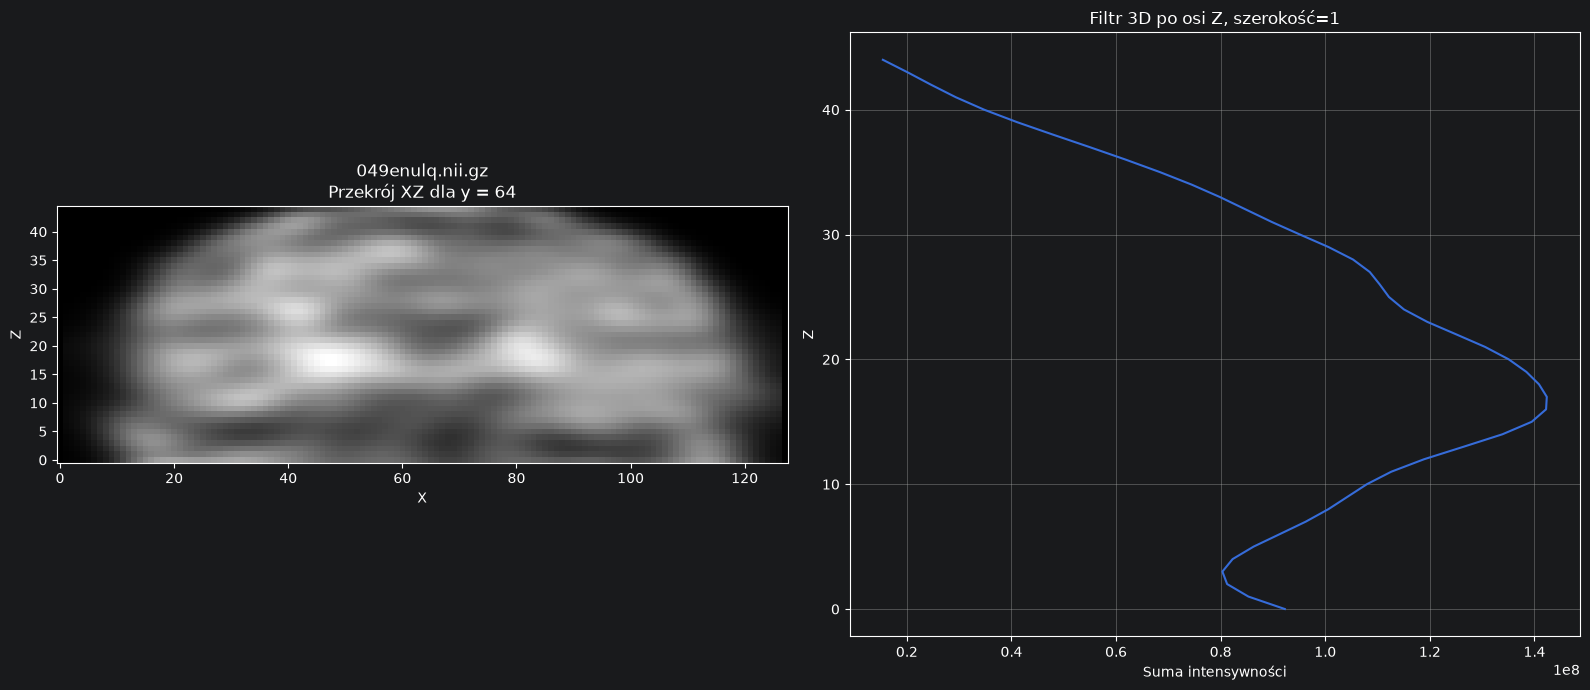


4/10: 04x0qzfh.nii.gz


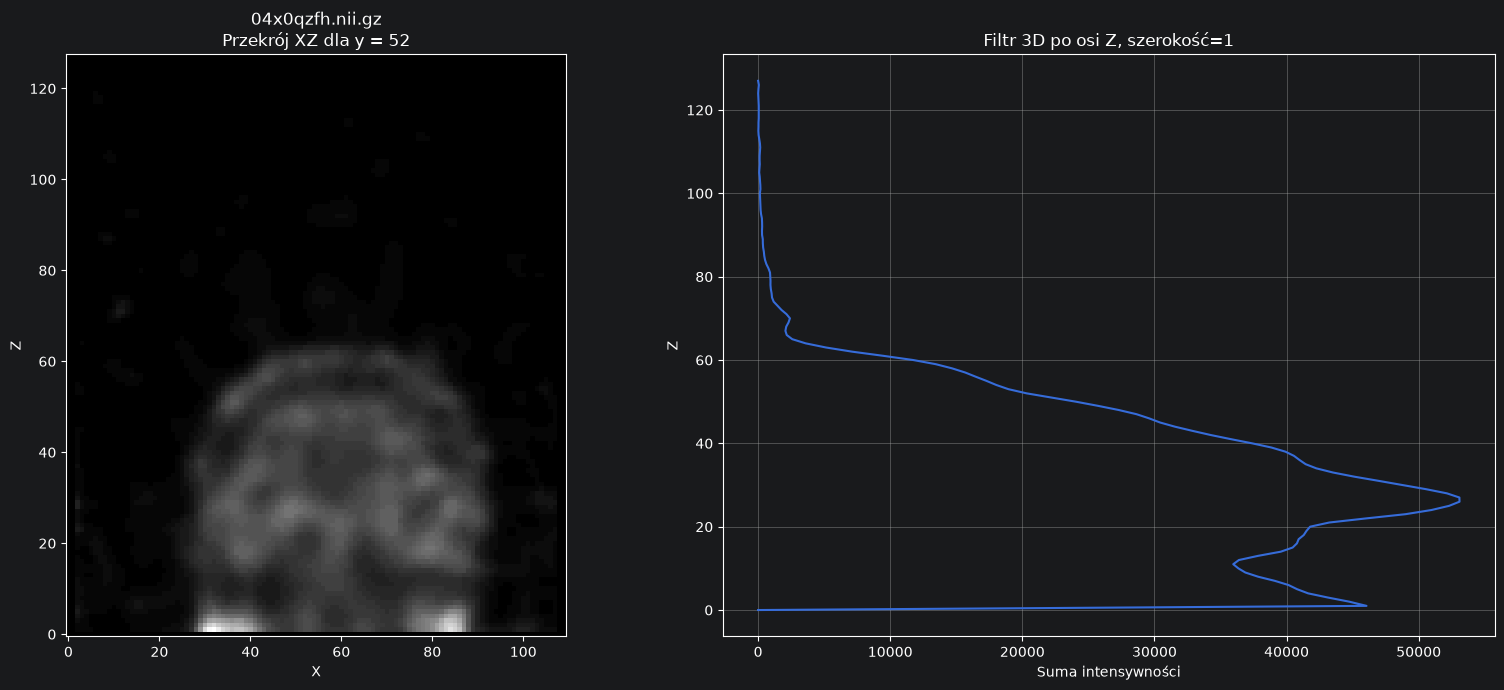


5/10: 05xt54fn.nii.gz


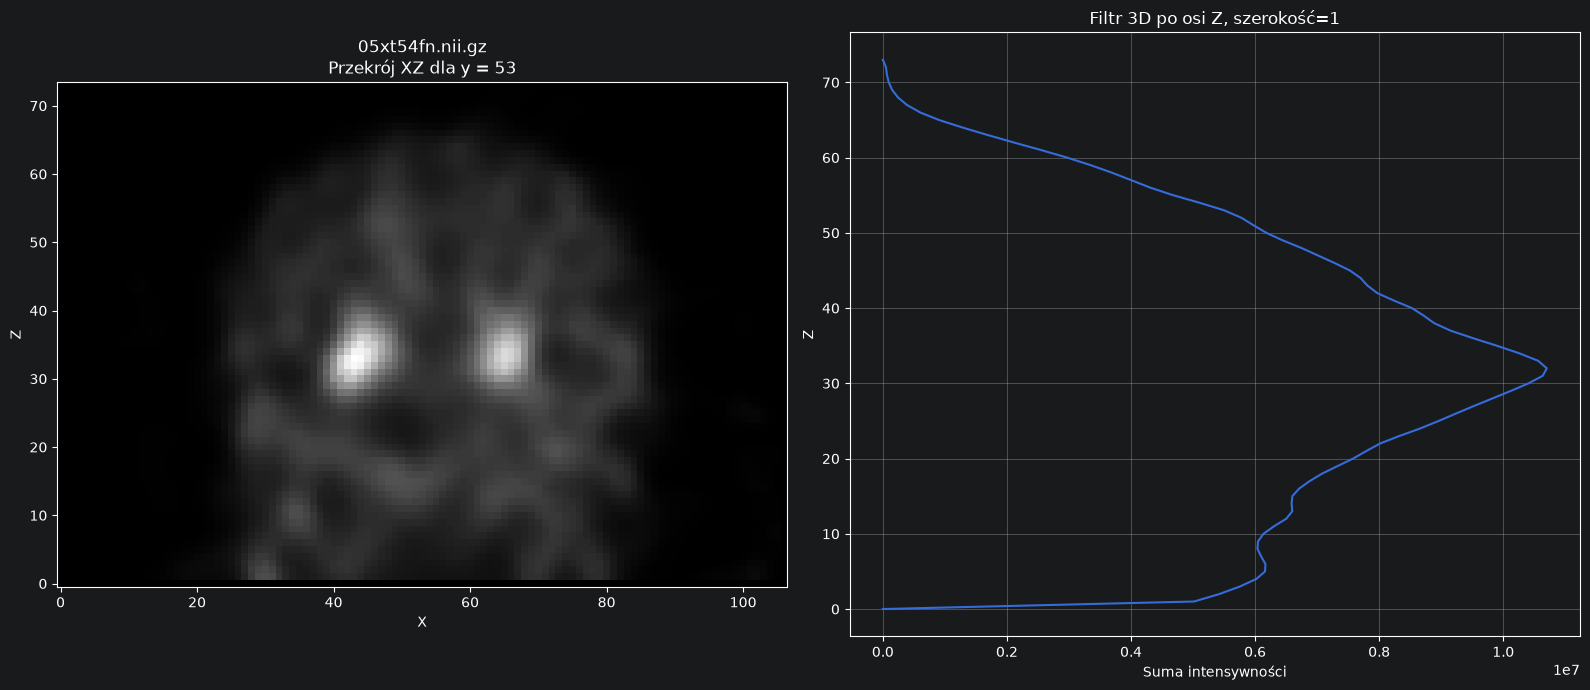


6/10: 06akt7zq.nii.gz


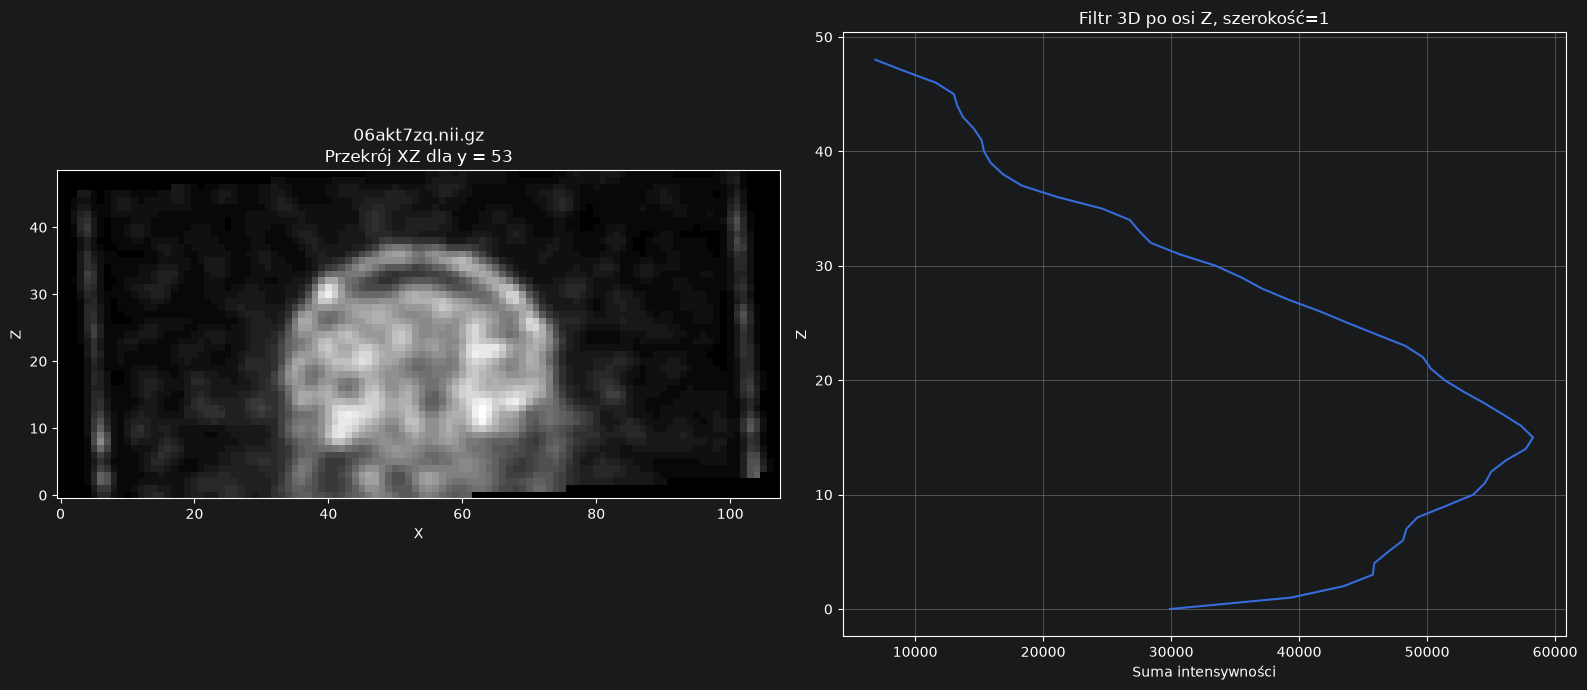


7/10: 06nkwfg3.nii.gz


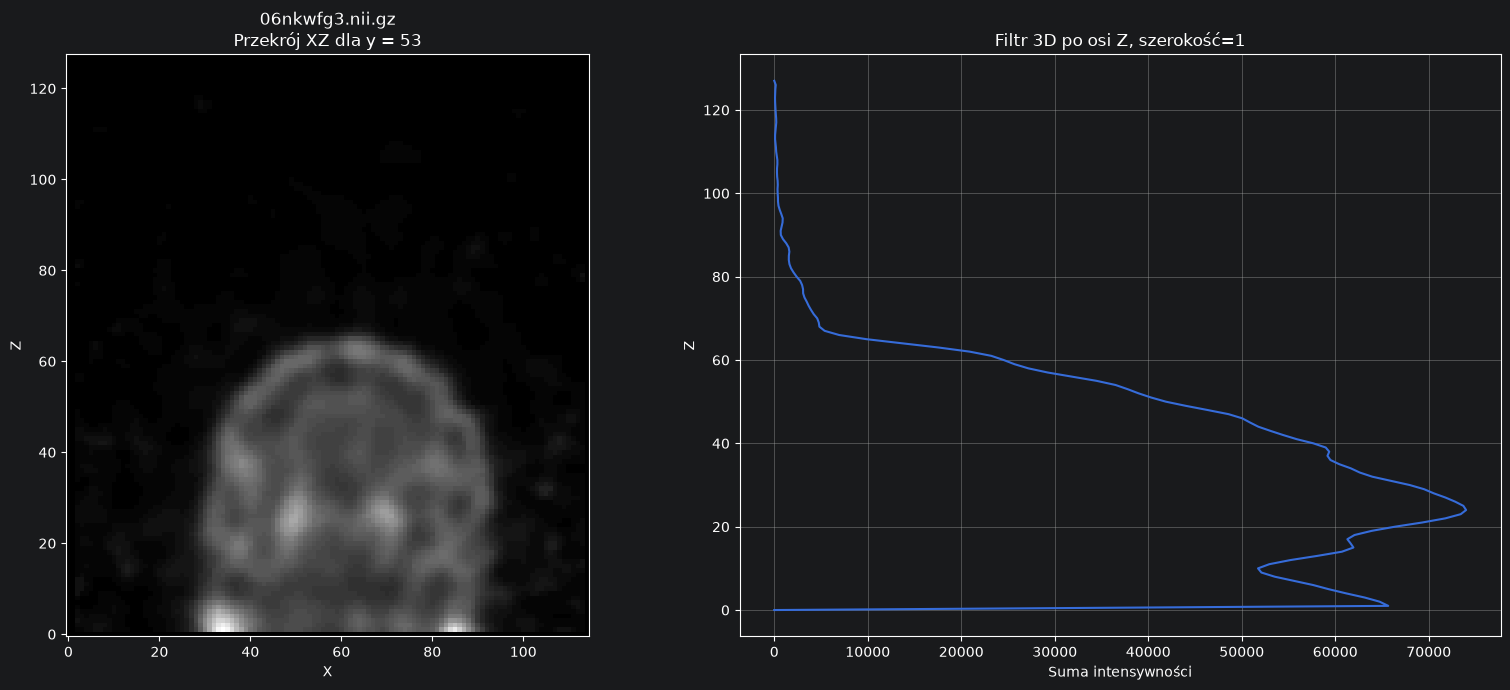


8/10: 07gbasf5.nii.gz


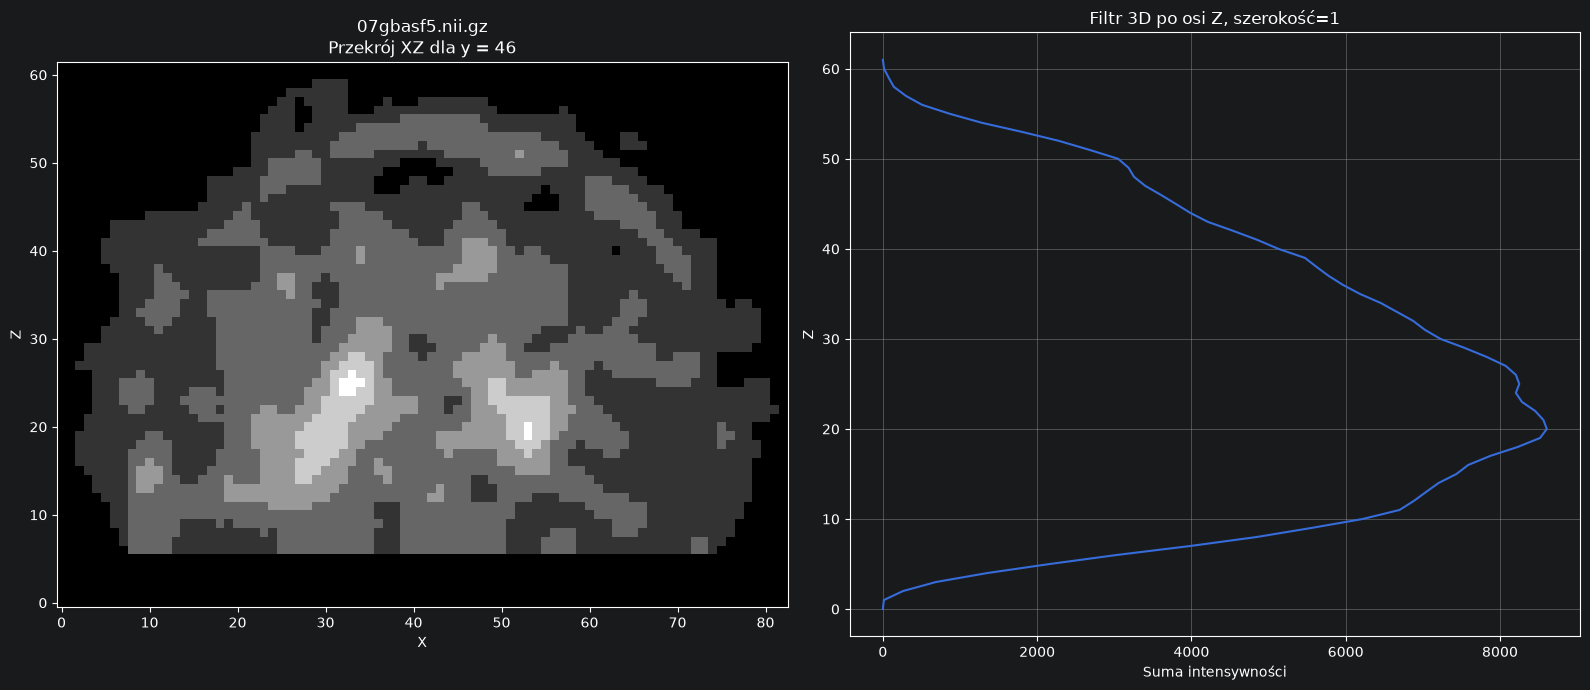


9/10: 07s387j5.nii.gz


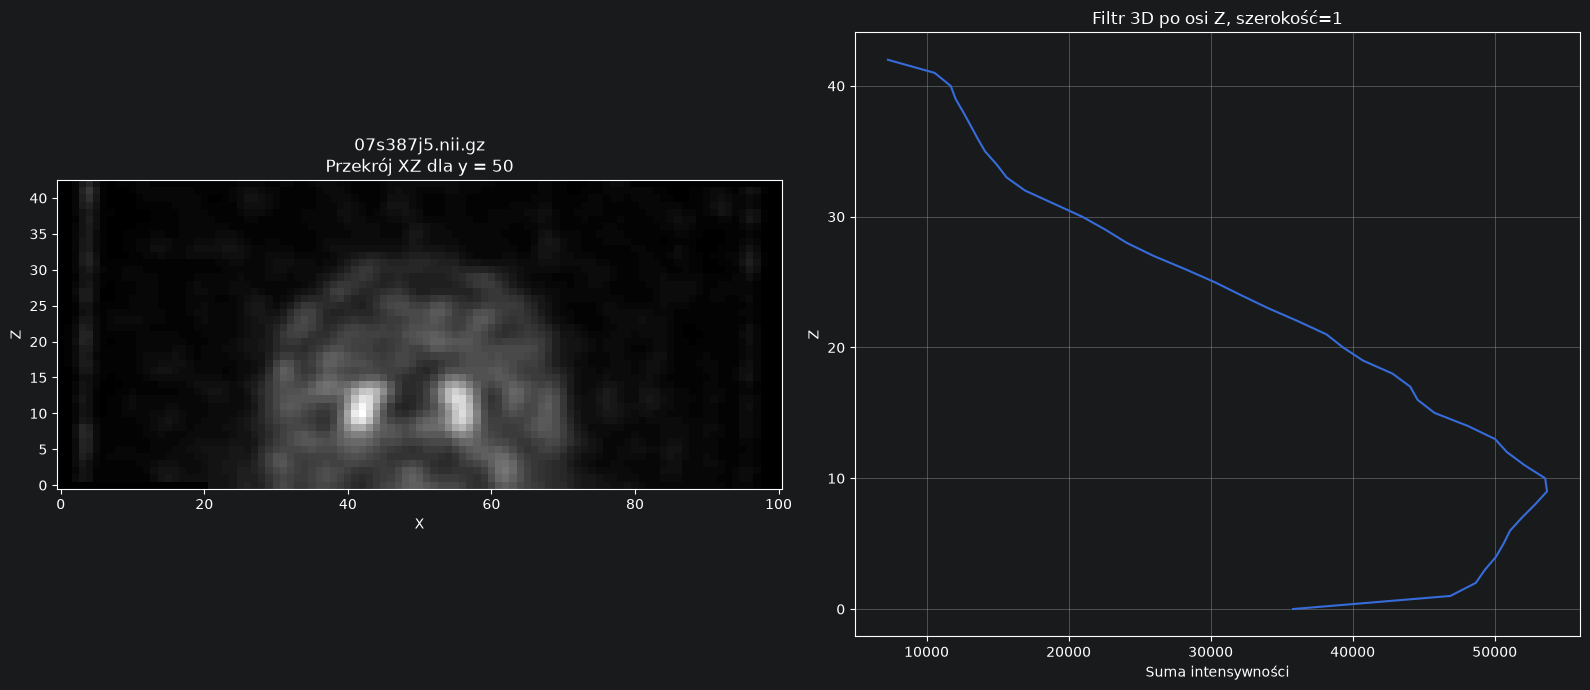


10/10: 085rntdr.nii.gz


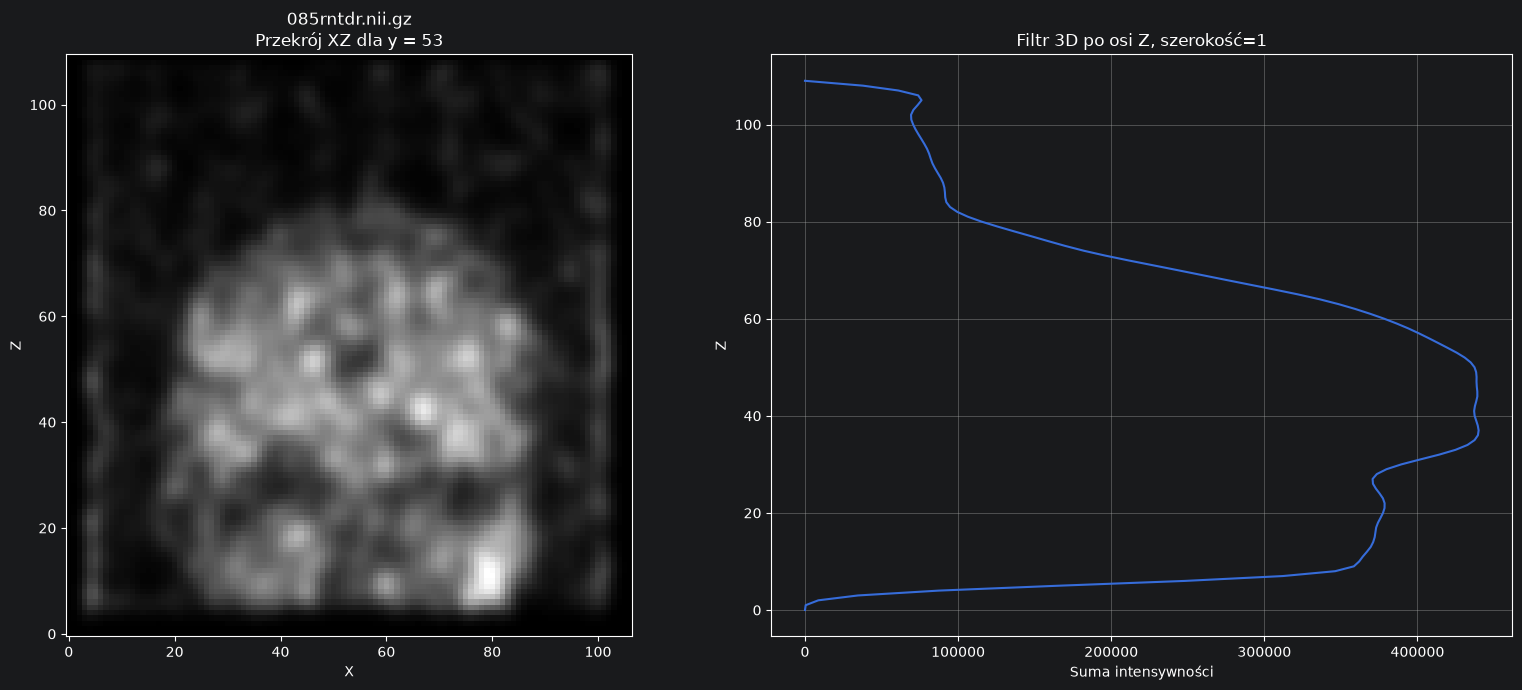

In [9]:
files = sorted(NIFTI_DIR.glob("*.nii.gz"))

filter_width = 1
n_images = 10

for i, file_path in enumerate(files[:n_images]):
    print(f"\n{i + 1}/{n_images}: {file_path.name}")

    cropped, _ = cut_off_black_segments(
        path=file_path,
        threshold=0,
        margin=1,
    )

    x_max, y_max, z_max = cropped.shape

    y = y_max // 2
    flat_plain_xz = cropped[:, y, :]

    filter_sum_3d_z = np.zeros(z_max - filter_width + 1)

    for z_pos in range(z_max - filter_width + 1):
        area = cropped[:, :, z_pos:z_pos + filter_width]
        filter_sum_3d_z[z_pos] = np.sum(area)

    z_positions = np.arange(len(filter_sum_3d_z)) + filter_width // 2

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].imshow(flat_plain_xz.T, cmap="gray", origin="lower")
    axes[0].set_title(
        f"{file_path.name}\n"
        f"Przekrój XZ dla y = {y}"
    )
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Z")

    axes[1].plot(filter_sum_3d_z, z_positions)
    # axes[1].invert_yaxis()
    axes[1].set_title(f"Filtr 3D po osi Z, szerokość={filter_width}")
    axes[1].set_xlabel("Suma intensywności")
    axes[1].set_ylabel("Z")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()